In [1]:
from beir.retrieval.evaluation import EvaluateRetrieval

from pymilvus import Collection, connections
import numpy as np
import pandas as pd

In [2]:
def evaluate_model_from_milvus(
    queries,
    collection: Collection,
    qrels,
    top_k_values=[1, 3, 5, 10, 20, 100]
):
    """
    queries: dict {query_id (int/str): embedding vector}
    qrels:   dict {query_id: {doc_id: relevance}}
    """
    # 1. Ép kiểu string - QUAN TRỌNG NHẤT
    qrels = {
        str(qid): {str(doc): int(rel) for doc, rel in docs.items()}
        for qid, docs in qrels.items()
    }
    
    results = {}
    max_k = max(top_k_values)

    search_params = {"metric_type": "COSINE", "params": {"M": 8, "efConstruction": 64}}
    
    for qid, q_emb in queries.items():
        qid_str = str(qid)
        
        hits = collection.search(
            data=[q_emb],
            anns_field="TextForEmbedding",
            param = search_params,
            limit=max_k,
            output_fields=["HotelID"],
            consistency_level="Strong"
        )[0]
        
        # SỬA LỖI None + ép str an toàn
        results[qid_str] = {}
        for hit in hits:
            doc_id = hit.entity.get("HotelID")
            if doc_id is not None:                     # <-- BẮT BUỘC KIỂM TRA
                results[qid_str][str(doc_id)] = float(hit.distance)
            # Nếu None thì bỏ qua, không thêm key 'None'

    # ĐÚNG CÁCH GỌI BEIR (KHÔNG trả về 4 biến!!!)
    metrics = EvaluateRetrieval.evaluate(
        qrels=qrels,
        results=results,           # dict đúng format
        k_values=top_k_values
    )
    
    # metrics là dict kiểu này:
    # {'NDCG@10': 0.4872, 'MAP@10': 0.3621, 'Recall@100': 0.721, ...}
    return metrics

In [3]:
connections.connect("default", host="localhost", port="19530")

In [2]:
df = pd.read_csv("../data/benchmark/relevance.csv")

In [5]:
def result(q_collection, d_collection, top_k=10):
    # query
    entities = q_collection.query(
        expr="",  # lấy tất cả
        limit = 46,
        output_fields=["query_id", "QueryForEmbedding"]
    )

    query_embeddings = {}
    for e in entities:
        query_id = e["query_id"]
        embedding = np.array(e["QueryForEmbedding"], dtype=np.float32)
        query_embeddings[query_id] = embedding

    # relevance
    qrels_dict = {}

    for _, row in df.iterrows():
        qid = row["query_id"]
        did = row["doc_id"]
        score = row["label"]
        
        if qid not in qrels_dict:
            qrels_dict[qid] = {}
        qrels_dict[qid][did] = score
        
    
    # --- Đánh giá model từ Milvus ---
    top_k_values = [top_k]
    
    final_metrics = evaluate_model_from_milvus(
        queries=query_embeddings,
        collection=milvus_collection,
        qrels=qrels_dict,
        top_k_values=top_k_values
    )

    ndcg, map_, recall, precision = final_metrics   # <-- unpack tuple

    # print("NDCG@10  :", ndcg["NDCG@10"])
    # print("MAP@10   :", map_["MAP@10"])
    # print("Recall@10 :", recall["Recall@10"])
    # print("P@10     :", precision["P@10"])
    
    # Nếu muốn in đẹp hơn cho nhiều k
    for k in [top_k]:
        if f"NDCG@{k}" in ndcg:
            print(f"NDCG@{k:>3}  : {ndcg[f'NDCG@{k}']:.4f}")
            print(f"MAP@{k:>3}   : {map_[f'MAP@{k}']:.4f}")
            print(f"P@{k:>3}     : {precision[f'P@{k}']:.4f}")
            print(f"Recall@{k:>3}: {recall[f'Recall@{k}']:.4f}")
            print("-" * 30)

In [6]:
collection = Collection("queries_mpnet_base_v2")
milvus_collection = Collection("docs_mpnet_base_v2")

In [7]:
print("model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
result(collection, milvus_collection)

model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
NDCG@10  : 0.47148
MAP@10   : 0.19328
Recall@10 : 0.2425
P@10     : 0.57609
NDCG@ 10  : 0.4715
MAP@ 10   : 0.1933
P@ 10     : 0.5761
Recall@ 10: 0.2425
------------------------------


In [8]:
collection = Collection("queries_e5_base_v2")
milvus_collection = Collection("docs_e5_base")

In [9]:
print("model : embaas/sentence-transformers-multilingual-e5-base")
result(collection, milvus_collection)

model : embaas/sentence-transformers-multilingual-e5-base
NDCG@10  : 0.28207
MAP@10   : 0.08179
Recall@10 : 0.13756
P@10     : 0.33043
NDCG@ 10  : 0.2821
MAP@ 10   : 0.0818
P@ 10     : 0.3304
Recall@ 10: 0.1376
------------------------------


In [13]:
collection = Collection("queries_e5_large_v2")
milvus_collection = Collection("docs_e5_lagre")

In [14]:
print("model : embaas/sentence-transformers-multilingual-e5-large")
result(collection, milvus_collection)

model : embaas/sentence-transformers-multilingual-e5-large
NDCG@10  : 0.30213
MAP@10   : 0.08817
Recall@10 : 0.14582
P@10     : 0.34783
NDCG@ 10  : 0.3021
MAP@ 10   : 0.0882
P@ 10     : 0.3478
Recall@ 10: 0.1458
------------------------------


In [15]:
collection = Collection("queries_MiniLM_L6_v2")
milvus_collection = Collection("docs_MiniLM_L6_v2")

In [16]:
print("model : sentence-transformers/all-MiniLM-L6-v2")
result(collection, milvus_collection)

model : sentence-transformers/all-MiniLM-L6-v2
NDCG@10  : 0.12282
MAP@10   : 0.02884
Recall@10 : 0.05802
P@10     : 0.13913
NDCG@ 10  : 0.1228
MAP@ 10   : 0.0288
P@ 10     : 0.1391
Recall@ 10: 0.0580
------------------------------


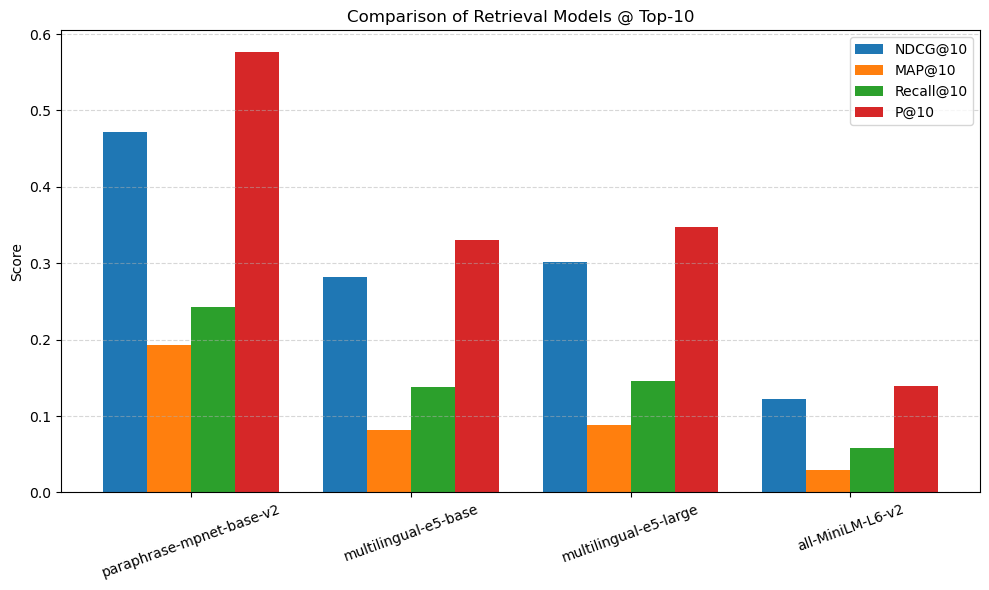

In [17]:
import matplotlib.pyplot as plt

# Tên các model
models = [
    "paraphrase-mpnet-base-v2",
    "multilingual-e5-base",
    "multilingual-e5-large",
    "all-MiniLM-L6-v2"
]

# Metrics @10
ndcg10 = [0.47148, 0.28207, 0.30213, 0.12282]
map10  = [0.19328, 0.08179, 0.08817, 0.02884]
recall10 = [0.2425, 0.13756, 0.14582, 0.05802]
p10 = [0.57609, 0.33043, 0.34783, 0.13913]

x = np.arange(len(models))  # vị trí trên trục x
width = 0.2  # độ rộng của mỗi bar

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - 1.5*width, ndcg10, width, label='NDCG@10')
ax.bar(x - 0.5*width, map10, width, label='MAP@10')
ax.bar(x + 0.5*width, recall10, width, label='Recall@10')
ax.bar(x + 1.5*width, p10, width, label='P@10')

ax.set_ylabel('Score')
ax.set_title('Comparison of Retrieval Models @ Top-10')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()